In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils import *
from models import *

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Normalization, Conv1D, Dense

In [58]:
## Levanto el dataset (unicamente los datos de acelerometro)
data = extraer_datos_csv(path='./Datasets/outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt', sensors= ['Bar','Temp'])

## Extraigo los Tags del dataset
tags = extraer_tags_csv(path='./Datasets/outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt')

print(f"El shape de data es: {data.shape}")
print(f"El shape de tags es: {tags.shape}")
print(tags)


El shape de data es: (2515, 520, 2)
El shape de tags es: (2515,)
[0 0 0 ... 1 1 1]


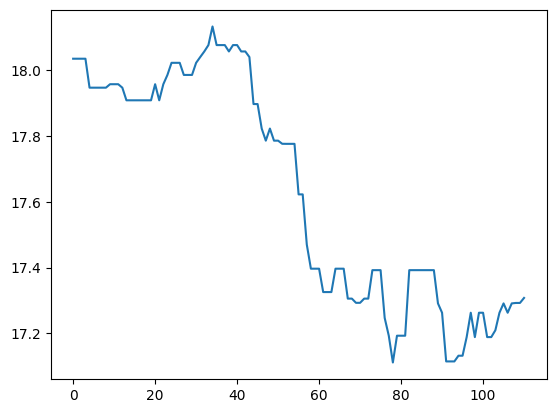

In [59]:
def median_filter(window , data):

    output = []

    for indx in range(window-1,len(data)):

        sorted_data = sorted(data[indx - window + 1: indx])
        output.append(sorted_data[window//2])

    return output

def calcular_altura(data ,window_filter = 10):
    data_output = []

    kernel = np.ones(window_filter) / window_filter

    for _data in data:
        sensor_temp =_data[: , 1]   
        sensor_temp = sensor_temp[~np.isnan(sensor_temp)]
        sensor_presion = _data[: , 0]    
        sensor_presion = sensor_presion[~np.isnan(sensor_presion)] 
        altura = ((sensor_temp + 273.15) / 0.0065) * (1 - (sensor_presion / 1013.25)**0.19)
        altura = median_filter(window_filter,altura)
        #altura = np.convolve(altura, kernel, mode='valid') ## similar a 
        #altura = pd.Series(altura)
        #altura = altura.rolling(window=window_filter).median()
        
        # data_output.append(altura[window_filter:])

        data_output.append(altura)
    return np.array(data_output)


alturas_mediciones = calcular_altura(data,20)

plt.plot(alturas_mediciones[-8])
    

Lo que tengo que hacer ahora es poder detectar solamente con la altura si es que hubo o no una caida. Una forma basica podria ser obtener el valor maximo, el minimo y con la diferencia evaluar si supera un humbral. De esta forma se detectaria que disminuyo la altura y en base a eso el sistema puede predecir que hubo algo similar a una caida. 
Tambien otra metrica que se puede obtener es la varianza de la señal. Tener una varianza muy alta o muy baja pueden ser sinonimos de actividad con mucho movimiento (aplaudir) o con poco movimiento (caminar)

In [60]:
# Feature diferencia de altura:

tags_caida = []

for escenario in alturas_mediciones: 

    var=  np.var(escenario)

    ####
    indx_max = np.argmax(escenario)
    indx_min = np.argmin(escenario)

    max = escenario[indx_max]
    min = escenario[indx_min]
    dif = max - min

    th = 0.8 # 80 cm

    if dif > th and indx_max < indx_min and 0.2 < var < 1:
        ## caida
        tags_caida.append(1)
    else:
        tags_caida.append(0)
        

    
# 4. Calculamos la matriz de confusión
matriz = confusion_matrix(tags, tags_caida)
print("\n=== MATRIZ DE CONFUSIÓN ===")
print("                  Predice NO CAÍDA   Predice CAÍDA")
print(f"Real NO CAÍDA:    {matriz[0][0]}                 {matriz[0][1]}")
print(f"Real CAÍDA:       {matriz[1][0]}                 {matriz[1][1]}")



=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    1866                 126
Real CAÍDA:       392                 131


Filtro movil x20, th = 0.8

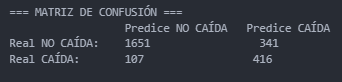

Filtro movil x10, th = 0.8

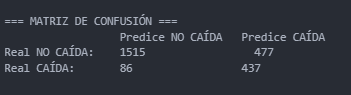

Filtro movil x20, th = 0.8, filtro de var

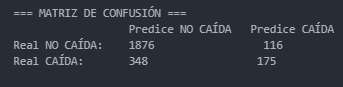

# Extraer features + redes neuronales

Lo que se propone ahora es tomar el enfoque previo, extraer features distintas y utilizarlas en una red neuronal simple para que prediga las acciones. Como input se toma la señal filtrada con un filtro de mediana que permite reducir el ruido del sensor sin opacar los movimientos bruzcos de la medicion (una caida).


In [61]:
## Features

min_indice = 0 
max_indice = 1
dif_altura_indice = 2
min_ubicacion_indice = 3
max_ubicacion_indice = 4
desvio_indice = 5
asimetria_indice = 6
curtosis_indice = 7
rms_indice = 8
percentil90_indice = 9
percentil10_indice = 10



def calcular_asimetria(señales, axis=1):
    """
    Calcula la asimetría (skewness) de un conjunto de señales.
    Se suma un epsilon (1e-10) a la desviación estándar para evitar divisiones por cero 
    en caso de que alguna señal sea una línea recta constante.
    """
    mu = np.mean(señales, axis=axis, keepdims=True)
    sigma = np.std(señales, axis=axis, keepdims=True) + 1e-10 
    
    # E[(X - mu / sigma)^3]
    asimetria = np.mean(((señales - mu) / sigma)**3, axis=axis)
    return asimetria

def calcular_curtosis(señales, axis=1):
    """
    Calcula el exceso de curtosis de un conjunto de señales.
    Una distribución normal perfecta devolverá 0.
    """
    mu = np.mean(señales, axis=axis, keepdims=True)
    sigma = np.std(señales, axis=axis, keepdims=True) + 1e-10
    
    # E[(X - mu / sigma)^4] - 3
    curtosis = np.mean(((señales - mu) / sigma)**4, axis=axis) - 3.0
    return curtosis

def extraer_features(señales):
    """
    Extrae 11 features de una matriz de señales [numero_señales, muestras].
    Retorna una matriz de dimensiones [numero_señales, 11].
    """
    # 0. min
    f_min = np.min(señales, axis=1)
    
    # 1. max
    f_max = np.max(señales, axis=1)
    
    # 2. dif_altura
    f_dif_altura = f_max - f_min
    
    # 3. min_ubicacion
    f_min_ubicacion = np.argmin(señales, axis=1)
    
    # 4. max_ubicacion
    f_max_ubicacion = np.argmax(señales, axis=1)
    
    # 5. desvio
    f_desvio = np.std(señales, axis=1)
    
    # 6. asimetria
    f_asimetria = calcular_asimetria(señales, axis=1)
    
    # 7. curtosis
    f_curtosis = calcular_curtosis(señales, axis=1)
    
    # 8. rms
    f_rms = np.sqrt(np.mean(señales**2, axis=1))
    
    # 9. percentil90
    f_percentil90 = np.percentile(señales, 90, axis=1)
    
    # 10. percentil10
    f_percentil10 = np.percentile(señales, 10, axis=1)
    
    # Agrupación en la matriz final de salida [numero_señales, 11]
    # np.column_stack toma arreglos 1D y los apila como columnas de una matriz 2D
    matriz_features = np.column_stack((
        f_min,
        f_max,
        f_dif_altura,
        f_min_ubicacion,
        f_max_ubicacion,
        f_desvio,
        f_asimetria,
        f_curtosis,
        f_rms,
        f_percentil90,
        f_percentil10
    ))
    
    return matriz_features



In [62]:
output = extraer_features(alturas_mediciones)
output.shape

(2515, 11)

In [63]:
data, data_val, tags, y_val  = train_test_split(output,tags, test_size=0.1, random_state=21)

data_train, data_test, y_train, y_test = train_test_split(data,tags, test_size=0.2, random_state=21)

In [ ]:
normalizador_entrada = Normalization()
normalizador_entrada.adapt(output)

nn = tf.keras.Sequential([
    normalizador_entrada, # Normaliza la entrada para mantener valores de distintas features en rangos similares
    layers.Dense(11,input_shape=(11, 1), activation = 'relu', kernel_regularizer = regularizers.L2(0.01)),
    layers.BatchNormalization(), # Normaliza los datos entre layers, esto se ajusta entre batches permite evitar que se saturen neuronas
    layers.Dense(4, activation = 'relu', kernel_regularizer = regularizers.L2(0.01)),
    layers.BatchNormalization(),
    layers.Dense(6, activation = 'relu', kernel_regularizer = regularizers.L2(0.01)),
    layers.Dropout(0.2), # Permite evitar que una unica neurona tenga conexiones muy fuertes apagandolas momentaneamente. Las demas neuronas deben ajustarse mas en esos casos reforzando sus conexiones.
    layers.BatchNormalization(),
    layers.Dense(units=1,activation="sigmoid", kernel_regularizer = regularizers.L2(0.01)),
])


nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy', 
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall')]
)

historial_1 = nn.fit(data_train, y_train,
                    epochs=250,
                    validation_data=(data_test, y_test))
nn.summary()




Epoch 1/250


/home/guido/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5569 - loss: 0.9744 - recall: 0.6398 - val_accuracy: 0.7660 - val_loss: 0.8380 - val_recall: 0.2658
Epoch 2/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5807 - loss: 0.9555 - recall: 0.6877 - val_accuracy: 0.7196 - val_loss: 0.8396 - val_recall: 0.5696
Epoch 3/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5983 - loss: 0.9296 - recall: 0.6851 - val_accuracy: 0.6777 - val_loss: 0.8526 - val_recall: 0.7848
Epoch 4/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5856 - loss: 0.9243 - recall: 0.6599 - val_accuracy: 0.6380 - val_loss: 0.8594 - val_recall: 0.7975
Epoch 5/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6061 - loss: 0.9044 - recall: 0.6826 - val_accuracy: 0.6137 - val_loss: 0.8609 - val_recall: 0.8101
Epoch 6/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6249 - loss: 0.8958 - recall: 0.6851 - val_accuracy: 0.6137 - val_loss: 0.8614 - val_recall: 0.8481
Epoch 7/250
57/57 ━━━━

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_6 (Normalization) │ (None, 11)             │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 11)             │            44 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 4)              │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 844 (3.30 KB)

 Trainable params: 259 (1.01 KB)

 Non-trainable params: 65 (264.00 B)

 Optimizer params: 520 (2.04 KB)

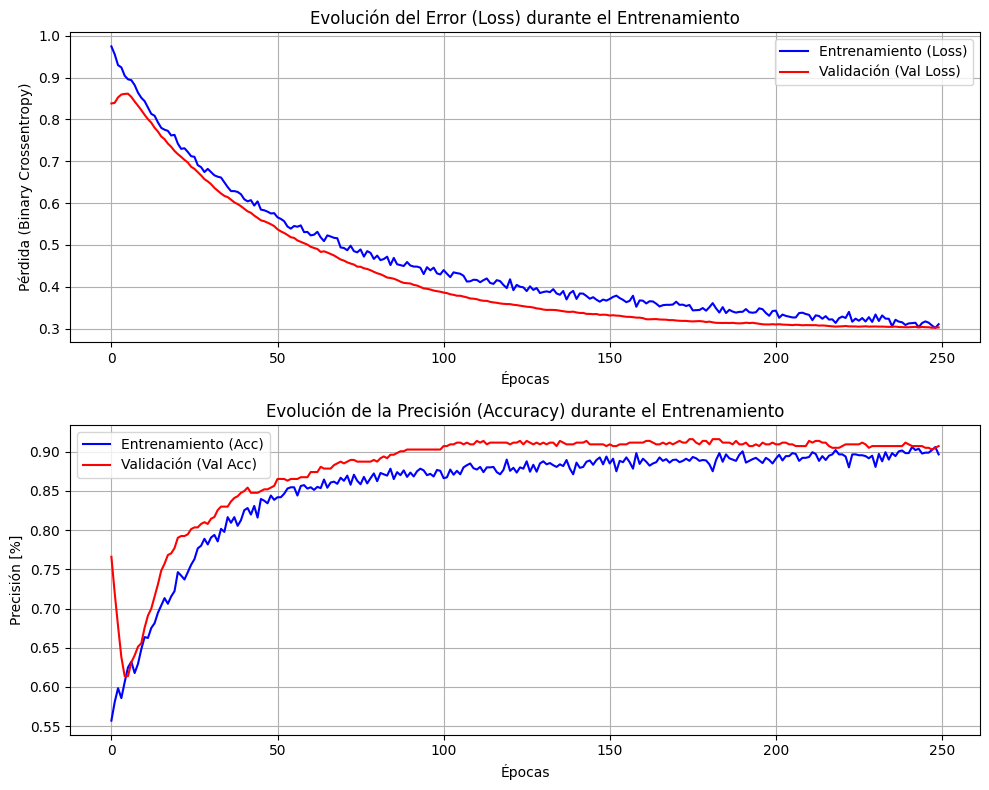

In [65]:
plot_stats(historial_1)
plt.show()

In [66]:
model_perfom(nn, data_val, y_val, threshold= 0.2)

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.96      0.90      0.93       205
    FALL (1)       0.67      0.85      0.75        47

    accuracy                           0.89       252
   macro avg       0.82      0.88      0.84       252
weighted avg       0.91      0.89      0.90       252


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    185                 20
Real CAÍDA:       7                 40


In [67]:
nn.save("./Modelos/modelo_barometro.keras")